# Módulo 2: Analítica Descriptiva y Visualización
**Data Analytics con Pronósticos a través de Python**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Carga y Exploración Inicial

In [10]:
# Crear dataset de ejemplo
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=200)
data = {
    'fecha': dates,
    'producto': np.random.choice(['A', 'B', 'C', 'D'], 200),
    'region': np.random.choice(['Norte', 'Sur', 'Centro', 'Oeste'], 200),
    'ventas': np.random.normal(1500, 400, 200).round(2),
    'cantidad': np.random.randint(20, 150, 200),
    'promocion': np.random.choice([0, 1], 200)
}
df = pd.DataFrame(data)
df.head()

,fecha,producto,region,ventas,cantidad,promocion
0,2023-01-01,C,Centro,1227.99,110,1
1,2023-01-02,D,Oeste,1592.90,109,0
2,2023-01-03,A,Centro,1617.23,38,1
3,2023-01-04,C,Norte,1214.26,58,0
4,2023-01-05,C,Oeste,2246.31,145,1


In [3]:
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fecha      200 non-null    datetime64[ns]
 1   producto   200 non-null    object        
 2   region     200 non-null    object        
 3   ventas     200 non-null    float64       
 4   cantidad   200 non-null    int64         
 5   promocion  200 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.5+ KB
None

Estadísticas descriptivas:
                     fecha   ventas  cantidad  promocion
count                  200   200.00    200.00     200.00
mean   2023-04-10 12:00:00  1526.97     82.88       0.51
min    2023-01-01 00:00:00   203.49     20.00       0.00
25%    2023-02-19 18:00:00  1233.75     49.00       0.00
50%    2023-04-10 12:00:00  1535.78     80.00       1.00
75%    2023-05-30 06:00:00  1766.60    115.50       1.00
max    

## 2. Análisis Descriptivo por Grupos

In [4]:
# Ventas por región
print(df.groupby('region')['ventas'].agg(['mean', 'sum', 'count']).round(2))

# Ventas por producto y región
pd.pivot_table(df, values='ventas', index='producto', columns='region', aggfunc='mean').round(2)

           mean       sum  count
region                          
Centro  1495.50  74775.16     50
Norte   1552.46  76070.31     49
Oeste   1506.92  91922.42     61
Sur     1565.63  62625.15     40


region,Centro,Norte,Oeste,Sur
producto,,,,
A,1393.90,1568.67,1624.80,1623.54
B,1380.70,1482.19,1424.12,1816.57
C,1428.80,1586.60,1664.29,1431.11
D,1723.81,1562.80,1327.91,1478.17


## 3. Visualizaciones

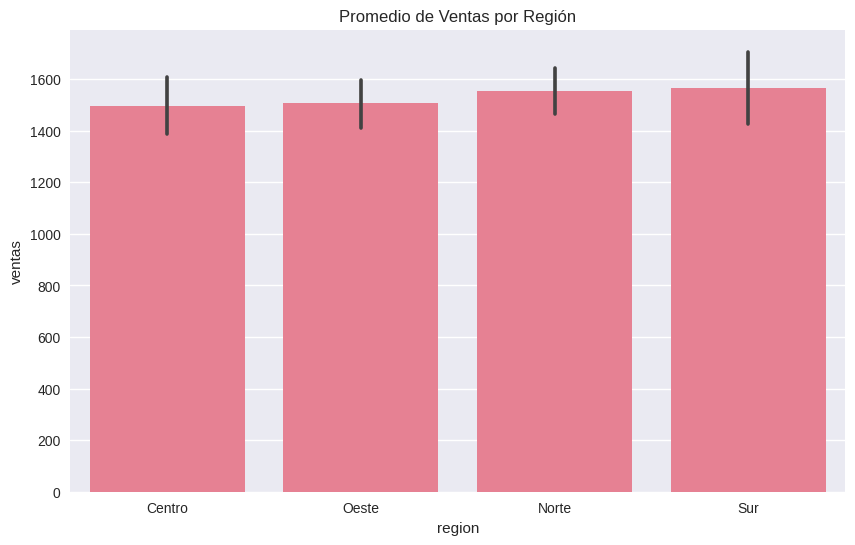

In [5]:
# 1. Barras - Ventas por Región
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='region', y='ventas', estimator=np.mean)
plt.title('Promedio de Ventas por Región')
plt.show()

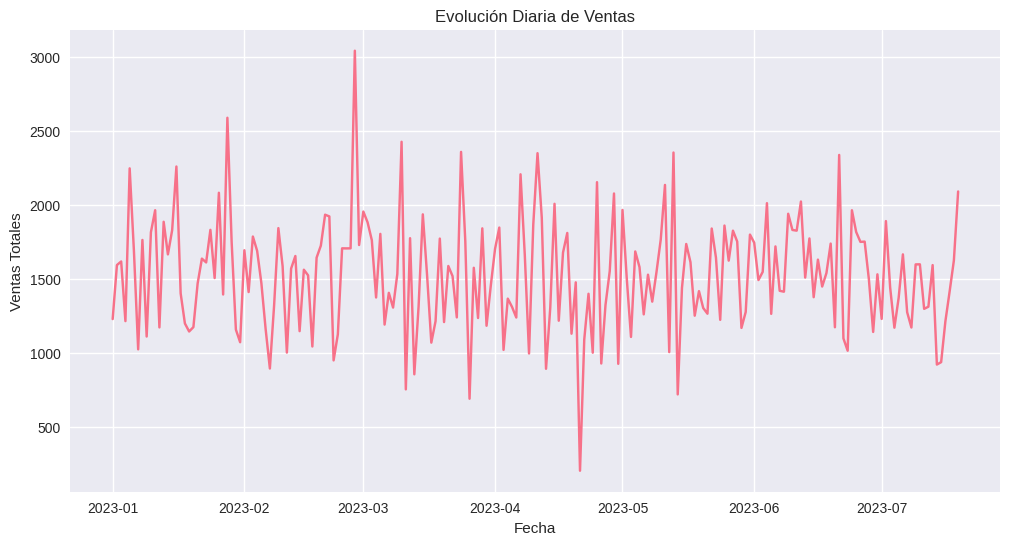

In [6]:
# 2. Línea Temporal
ventas_diarias = df.groupby('fecha')['ventas'].sum()
plt.figure(figsize=(12,6))
plt.plot(ventas_diarias)
plt.title('Evolución Diaria de Ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True)
plt.show()

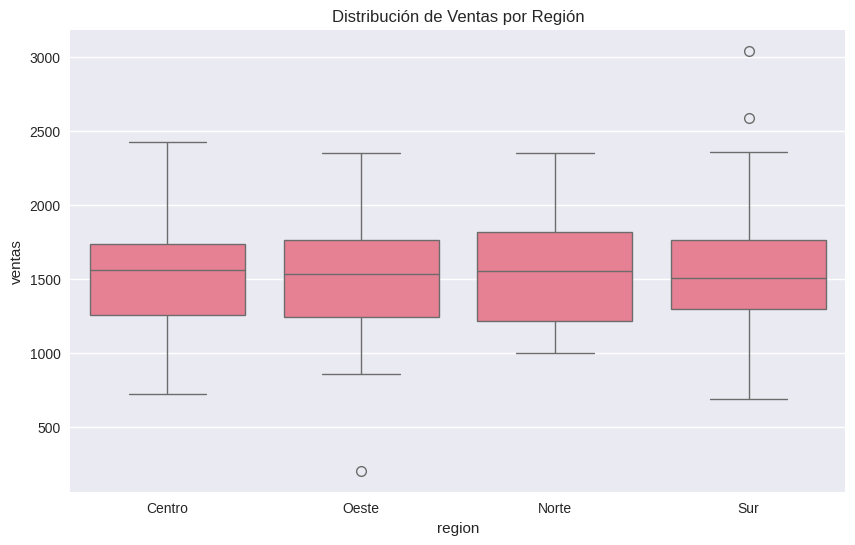

In [7]:
# 3. Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='region', y='ventas', data=df)
plt.title('Distribución de Ventas por Región')
plt.show()

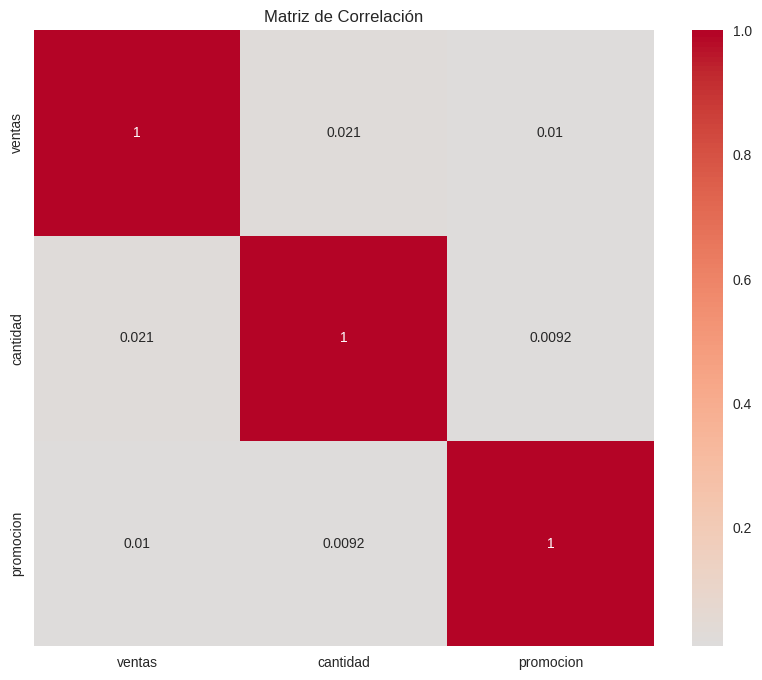

In [8]:
# 4. Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

**¡Fin del Módulo 2!** Guarda este notebook y prepara tu análisis descriptivo completo.